In [189]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 

In [190]:
# Definimos función cuadrática
def cuadrat(x, A, B, C): 
    y = np.multiply(A, np.power(x,2)) + np.multiply(B, x) + C
    return y 

Datos de tiempo inventados:

In [192]:
t = [33.444, 33.496, 33.540, 33.577, 33.608, 33.637, 33.663, 33.688, 33.712, 33.735]

Recalculamos los tiempos haciendo t0 = 33.444 --> t0 = 0

In [193]:
tcorr = np.subtract(t,t[0])

In [194]:
tcorr

array([0.   , 0.052, 0.096, 0.133, 0.164, 0.193, 0.219, 0.244, 0.268,
       0.291])

Datos de posición inventados:

In [195]:
x = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]

In [196]:
x_sigma = [0.01, 0.05, 0.001, 0.07, 0.1, 0.001, 0.008, 0.06, 0.05, 0.1]

In [197]:
xcorr = np.subtract(x,x[0])

In [198]:
xcorr

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

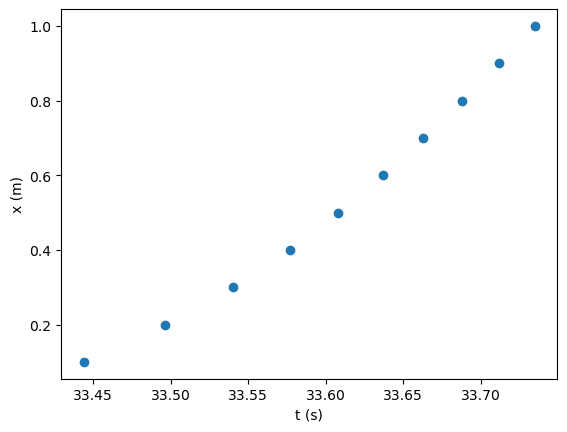

In [199]:
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.plot(t, x,'o') 

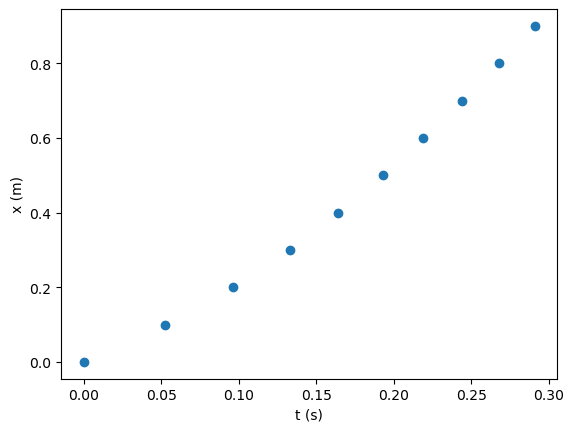

In [200]:
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.plot(tcorr, xcorr,'o') 

In [201]:
# Propuesta de parámetros iniciales para el ajuste no lineal

param_inicial = [1.0, 1.0, 0.0]

In [202]:
parameters, covariance = curve_fit(cuadrat, tcorr,  xcorr, p0=param_inicial, sigma = x_sigma) 
  
fit_A = parameters[0] 
fit_B = parameters[1] 
fit_C = parameters[2] 
u_A = np.sqrt(np.diag(covariance)[0])
u_B = np.sqrt(np.diag(covariance)[1])
u_C = np.sqrt(np.diag(covariance)[2])

In [203]:
fit_A

5.276143792065779

In [204]:
u_A

0.0710600844675388

In [205]:
print(f"A = {fit_A:.2f} \u00B1 {u_A:.2f} unidades de A")

A = 5.28 ± 0.07 unidades de A


In [206]:
fit_B

1.5688319883227433

In [207]:
u_B

0.020312284856706365

In [208]:
print(f"B = {fit_B:.3f} \u00B1 {u_B:.3f} unidades de B")

B = 1.569 ± 0.020 unidades de B


In [209]:
fit_C

0.0007431261447050497

In [210]:
u_C

0.0012957499929324692

In [211]:
print(f"C = {fit_C:.4f} \u00B1 {u_C:.4f} unidades de C")

C = 0.0007 ± 0.0013 unidades de C


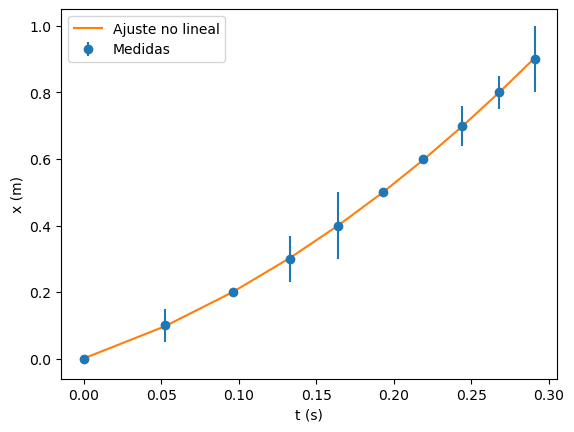

In [212]:
fit_y = cuadrat(tcorr, fit_A, fit_B, fit_C) 
#plt.plot(tcorr, xcorr, 'o', label='Medidas experimentales') 
plt.errorbar(tcorr, xcorr, yerr=x_sigma, linestyle='None', marker='o', label='Medidas')
plt.plot(tcorr, fit_y, '-', label='Ajuste no lineal') 
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.legend()

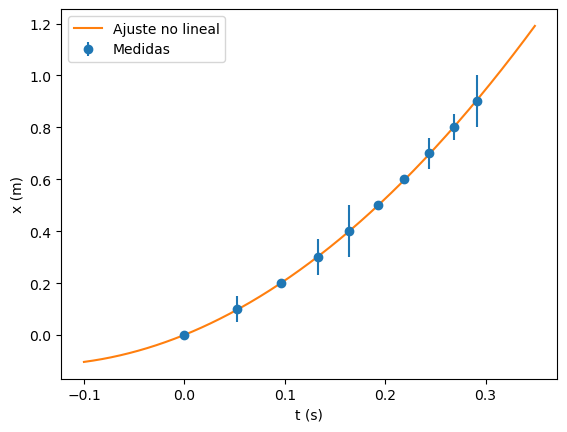

In [215]:
t_fit = np.arange(-0.1, 0.35, 0.001) 
fit_y = cuadrat(t_fit, fit_A, fit_B, fit_C) 
#plt.plot(tcorr, xcorr, 'o', label='Medidas experimentales') 
plt.errorbar(tcorr, xcorr, yerr=x_sigma, linestyle='None', marker='o', label='Medidas')
plt.plot(t_fit, fit_y, '-', label='Ajuste no lineal') 
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.legend()